Acest proiect are ca scop dezvoltarea unui model capabil să estimeze scorul de recuperare al atleților (Recovery_Score), în funcție de date biometrice, comportamentale și de antrenament. Metodologia pe care am respectat-o în dezvoltarea acestui proiect este KDD: Selecția datelor, preprocesare, antrenare model, evaluare și interpretare.

Importurile bibliotecilor - Bibliotecile esențiale pentru manipularea datelor, vizualizare, preprocesare și splituri, modele de regresie și metricile de evaluare

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import OrdinalEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)




Încărcarea datelor. Afișăm primele 15 înregistrări pentru a avea o imagine inițială a datelor

In [2]:
df = pd.read_csv("recovery.csv")

df.head(15)





,Athlete_ID,Day,Day_of_Week,Week,Age,Gender,Sport_Type,Training_Type,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
0,1000,1,1,1,28,Male,Team Sport,HIIT,46,7.9,7.7,270,High,59,75,4.3,4.8,5.9,51.1
1,1000,2,2,1,28,Male,Team Sport,Cardio,71,7.0,7.3,258,Low,55,79,5.9,4.0,5.8,63.7
2,1000,3,3,1,28,Male,Team Sport,HIIT,45,7.3,7.7,214,Medium,57,77,5.1,4.0,5.6,71.0
3,1000,4,4,1,28,Male,Team Sport,Cardio,86,7.5,7.9,228,High,61,71,3.0,6.2,2.7,37.2
4,1000,5,5,1,28,Male,Team Sport,HIIT,28,9.2,6.7,0,High,64,62,3.3,7.4,1.1,12.3
5,1000,6,6,1,28,Male,Team Sport,Cardio,70,5.5,8.4,149,Low,58,79,6.2,5.1,3.1,82.3
6,1000,7,7,1,28,Male,Team Sport,Yoga,42,2.9,7.8,217,Medium,59,73,5.2,3.5,4.1,44.5
7,1000,8,1,2,28,Male,Team Sport,Strength,63,7.7,7.8,343,High,60,65,4.3,7.6,1.0,25.1
8,1000,9,2,2,28,Male,Team Sport,HIIT,54,9.4,8.0,216,High,61,68,4.9,7.2,1.1,27.4
9,1000,10,3,2,28,Male,Team Sport,Strength,78,8.5,5.9,299,High,67,59,2.7,8.0,1.0,0.0


Explorarea datelor. Înainte de a începe preprocesarea, identificăm coloanele care conțin valori lipsă și calculăm procentajul acestora.

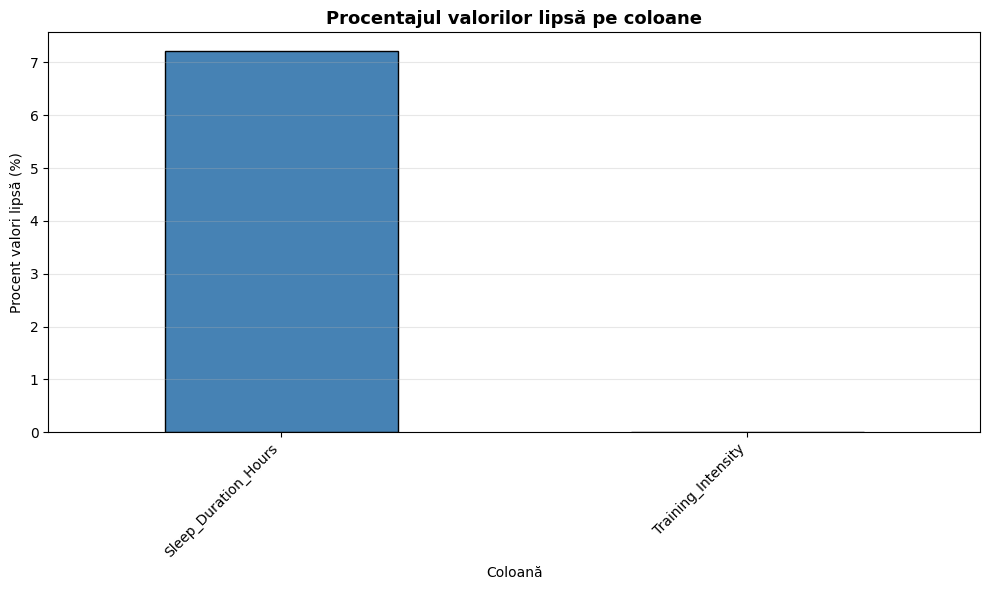


Detalii valori lipsă 
                                     ColName      Nan%
Sleep_Duration_Hours    Sleep_Duration_Hours  7.208497
Training_Intensity        Training_Intensity  0.011935
Athlete_ID                        Athlete_ID  0.000000
Day_of_Week                      Day_of_Week  0.000000
Day                                      Day  0.000000
Week                                    Week  0.000000
Age                                      Age  0.000000
Sport_Type                        Sport_Type  0.000000
Gender                                Gender  0.000000
Training_Duration_Min  Training_Duration_Min  0.000000


In [3]:
NanPercent = pd.DataFrame({
    'ColName': df.columns,
    'Nan%': np.sum(df.isnull(), axis=0) / len(df) * 100
})
NanPercent.sort_values('Nan%', ascending=False, inplace=True)

NanPercent_filtered = NanPercent[NanPercent['Nan%'] > 0]

if len(NanPercent_filtered) > 0:
    NanPercent_filtered.plot.bar(x='ColName', y='Nan%', figsize=(10, 6),
                                  legend=False, color='steelblue', edgecolor='black')
    plt.title('Procentajul valorilor lipsă pe coloane', fontsize=13, fontweight='bold')
    plt.ylabel('Procent valori lipsă (%)')
    plt.xlabel('Coloană')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Nu există valori lipsă în setul de date.")

print("\nDetalii valori lipsă ")
print(NanPercent.head(10))

Distributia variabilei tintă. Analizăm distribuția variabilei Recovery_Score pe care îcercăm să o prezicem.

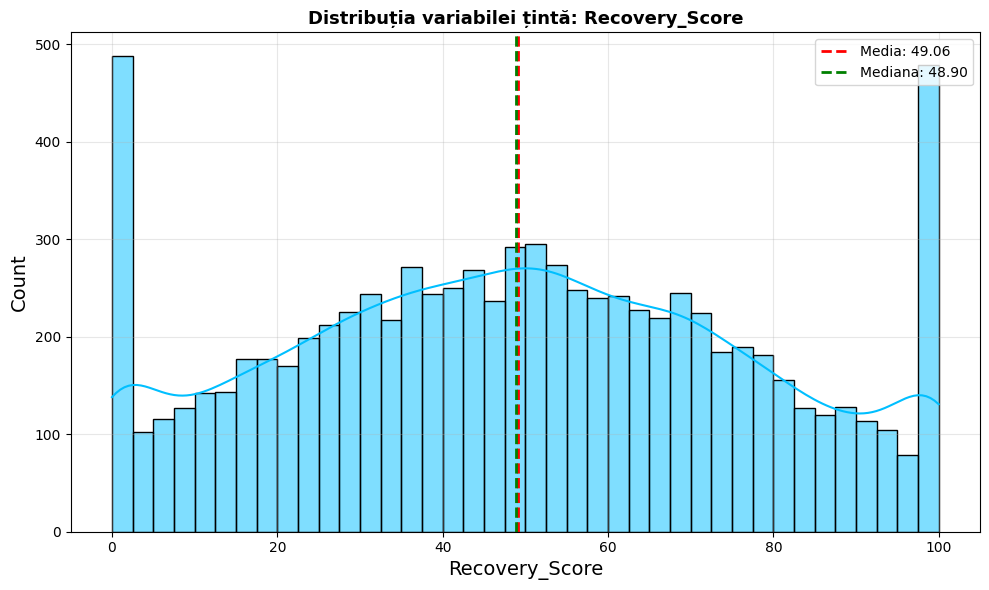


=== Statistici descriptive Recovery_Score ===
count    8379.000000
mean       49.061356
std        27.926347
min         0.000000
25%        27.800000
50%        48.900000
75%        69.900000
max       100.000000
Name: Recovery_Score, dtype: float64


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

p = sns.histplot(x=df['Recovery_Score'], kde=True, bins=40,
                 color='deepskyblue', edgecolor='black', ax=ax)

ax.axvline(df['Recovery_Score'].mean(), color='red', linestyle='--',
           linewidth=2, label=f'Media: {df["Recovery_Score"].mean():.2f}')
ax.axvline(df['Recovery_Score'].median(), color='green', linestyle='--',
           linewidth=2, label=f'Mediana: {df["Recovery_Score"].median():.2f}')

p.set_xlabel('Recovery_Score', fontsize=14)
p.set_ylabel('Count', fontsize=14)
ax.set_title('Distribuția variabilei țintă: Recovery_Score', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n=== Statistici descriptive Recovery_Score ===")
print(df['Recovery_Score'].describe())

Distribuția centrală este normală. Am observat acumulări semnificative la limite (0,100), ceea ce sugerează o potențială operație de trunchiere aplicată în generarea datelor, dat fiind caracterul sintetic al setului de date.  

Distribuția variabilelor numerice. Vizualizăm distribuția fiecărei variabile numerice pentru a identifica forma acesteia, posibili outlieri și variabilele categorice

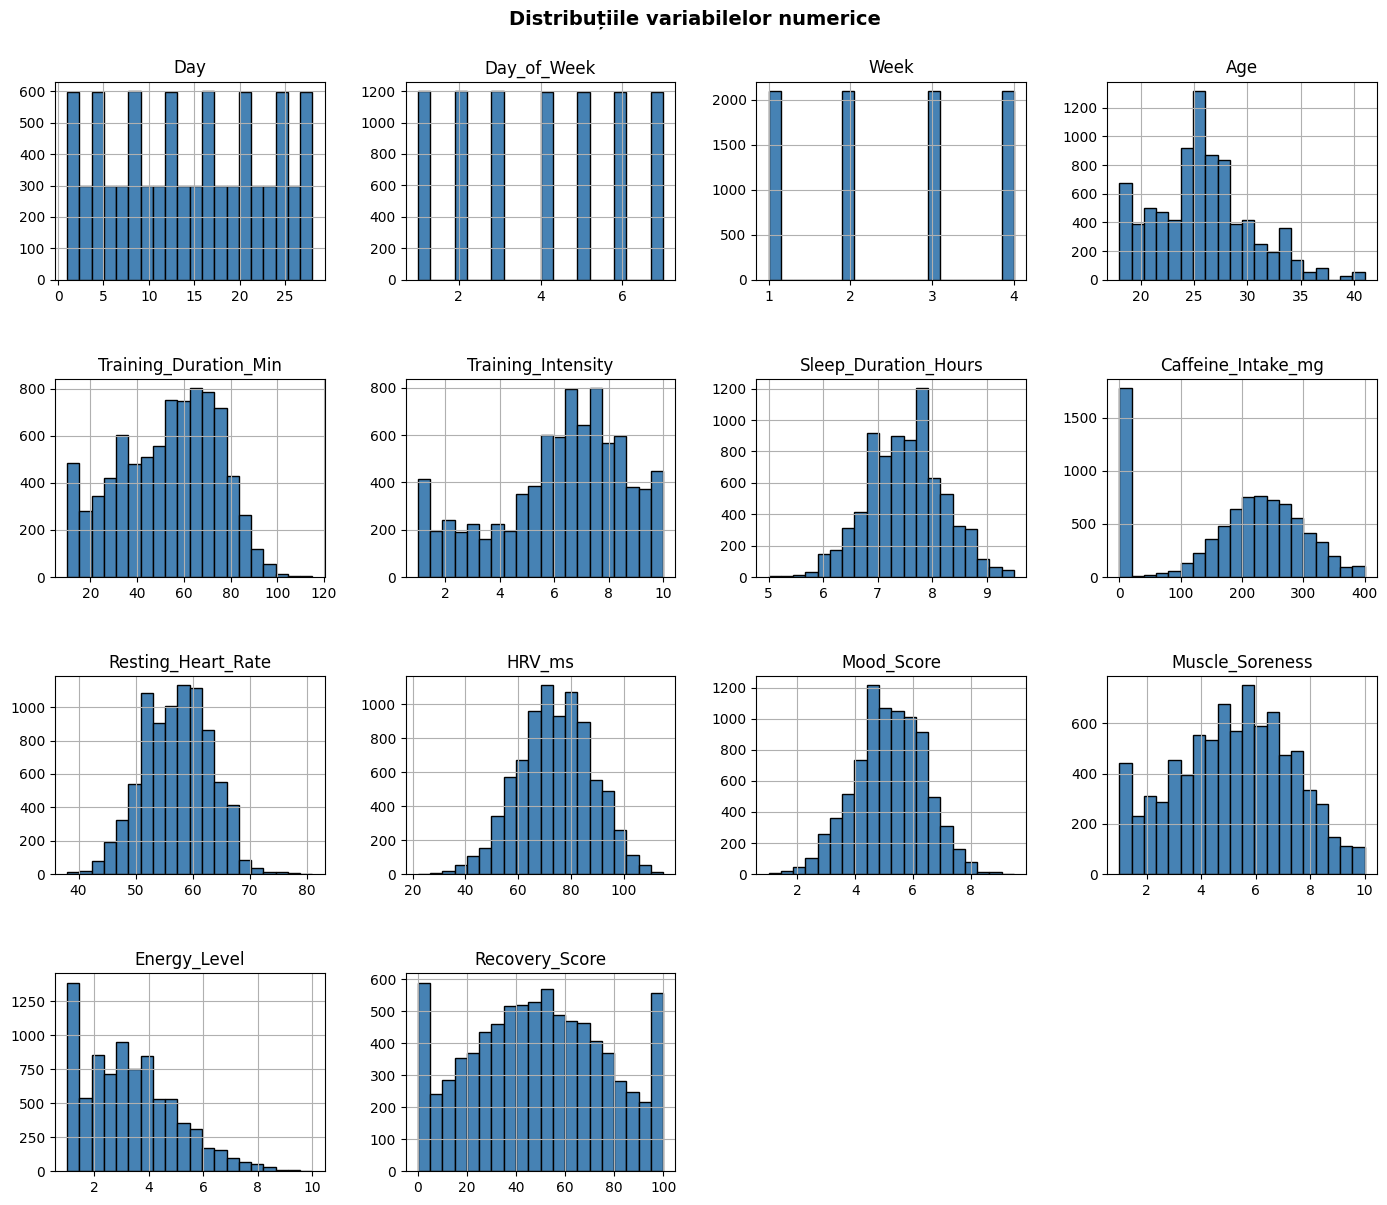

In [5]:
numerical_data = df.select_dtypes(include=np.number).drop(columns=['Athlete_ID'], errors='ignore')

numerical_data.hist(bins=20, figsize=(14, 12), edgecolor='black', layout=(4, 4), color='steelblue')
plt.suptitle('Distribuțiile variabilelor numerice', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

Matricea de corelatie. Analizăm relațiile liniare dintre variabilele numerice prin coeficientul Pearson. Pentru claritate vizuală, afișăm doar jumătatea inferioară a matricei (fiind simterică) și filtrăm corelațiile slabe (valorile din intervalul [-0.3; +0.3] ) la valoarea 0, evidențiind doar relațiile semnificative.

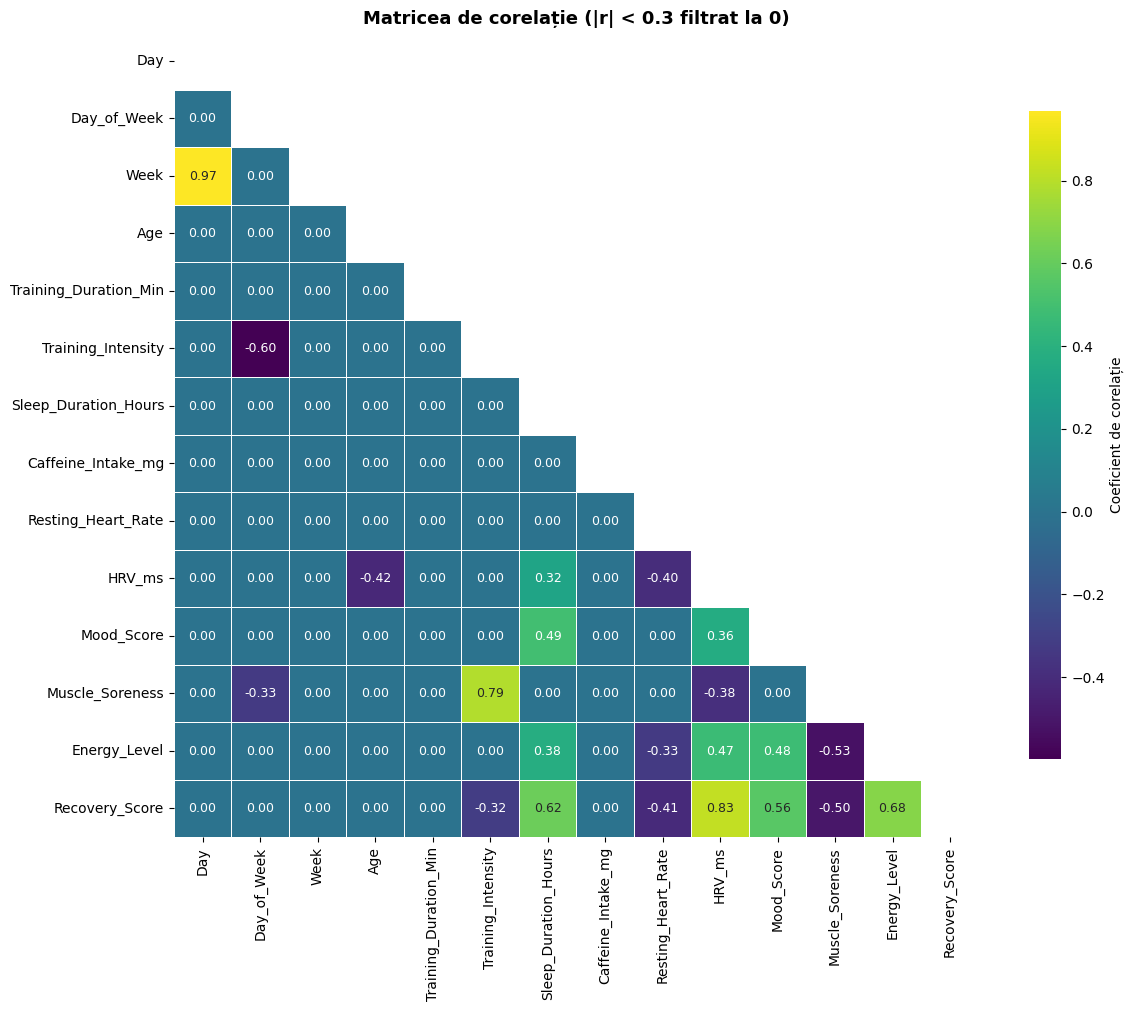


=== Top corelații cu Recovery_Score ===
HRV_ms                  0.83
Energy_Level            0.68
Sleep_Duration_Hours    0.62
Mood_Score              0.56
Muscle_Soreness        -0.50
Resting_Heart_Rate     -0.41
Training_Intensity     -0.32
Age                    -0.22
Caffeine_Intake_mg     -0.20
Week                   -0.16
Name: Recovery_Score, dtype: float64


In [6]:
pd.options.display.float_format = "{:,.2f}".format

corr_matrix = numerical_data.corr()

corr_matrix_filtered = corr_matrix.copy()
corr_matrix_filtered[(corr_matrix_filtered < 0.3) & (corr_matrix_filtered > -0.3)] = 0

mask = np.triu(np.ones_like(corr_matrix_filtered, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix_filtered, mask=mask, cmap='viridis', annot=True,
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Coeficient de corelație"},
            annot_kws={"size": 9}, ax=ax)
ax.set_title('Matricea de corelație (|r| < 0.3 filtrat la 0)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Top corelații cu Recovery_Score ===")
target_corr = corr_matrix['Recovery_Score'].drop('Recovery_Score').sort_values(key=abs, ascending=False)
print(target_corr.head(10))

Se observă câteva corelații semnificative cu variabila țintă.
*   HRV_ms (+0.83) este predictorul dominant, corelație foarte puternică pozitivă
*   Energy_Level (+0.68), Sleep_Duration_Hours (+0.62) — predictori pozitivi puternici
*  Muscle_Soreness (-0.50), Resting_Heart_Rate (-0.41) — corelații negative moderate
*   Training_Intensity (-0.32) — corelație negativă slab-moderată  

Alte observații dintre restul variabilelor:
*  Day - Week (+0.97) — variabile temporale puternic legate
* Training_Intensity - Muscle_Soreness (+0.79) — antrenamentul intens cauzează durere musculară
* Energy_Level - Muscle_Soreness (-0.53) — durerea musculară reduce energia










Preprocesare datelor.

Având în vedere că doar Sleep_Duration_Hours și Training_Intensity prezintă valori lipsă, variabilele afectate sunt continue și aproximativ normal distribuite, iar procentul valorilor lipsă este mic, am ales să  folosim imputarea cu media ca strategie. Această abordare păstrează dimensiunea completă a setului de date și nu introduce bias semnificativ. Eliminarea rândurilor ar fi produs o pierdere de 600 de observații, pierdere nejustificată față de proporția mică de valori lipsă.

In [7]:
df['Sleep_Duration_Hours'] = df['Sleep_Duration_Hours'].fillna(df['Sleep_Duration_Hours'].mean())
df['Training_Intensity'] = df['Training_Intensity'].fillna(df['Training_Intensity'].mean())

Detectarea outlierilor folosind formula IQR. Identificăm valorile extreme prin metoda Interquartile Range, care marchează ca și outlieri valorile care se află:

*   Sub limita inferioară: Q1 - 1.5 x IQR
*   Peste limita superioară: Q3 + 1.5 x IQR
Q1 și Q3 reprezintă cuartila 1 și  cuartila 3, iar IQR = Q3 - Q1


In [8]:
Q1 = df.select_dtypes(include=np.number).quantile(0.25)
Q3 = df.select_dtypes(include=np.number).quantile(0.75)
IQR = Q3 - Q1

outliers = ((df.select_dtypes(include=np.number) < (Q1 - 1.5 * IQR)) |
            (df.select_dtypes(include=np.number) > (Q3 + 1.5 * IQR))).sum()

outliers

,0
Athlete_ID,0
Day,0
Day_of_Week,0
Week,0
Age,223
Training_Duration_Min,0
Training_Intensity,0
Sleep_Duration_Hours,119
Caffeine_Intake_mg,0
Resting_Heart_Rate,39


Pentru coloanele identificate cu un număr semnificativ de oulieri, verificăm valorile minime și maxime prin describe(), pentru a decide dacă sunt valori plauzibile fiziologic sau erori care ar trebui eliminate


In [9]:
df[['Age', 'Energy_Level', 'Mood_Score', 'HRV_ms', 'Resting_Heart_Rate']].describe()

,Age,Energy_Level,Mood_Score,HRV_ms,Resting_Heart_Rate
count,"8,379.00","8,379.00","8,379.00","8,379.00","8,379.00"
mean,25.86,3.27,5.18,74.13,57.20
std,4.53,1.68,1.21,13.98,5.79
min,18.00,1.00,1.00,22.00,38.00
25%,23.00,2.00,4.40,64.00,53.00
50%,26.00,3.10,5.20,74.00,58.00
75%,28.00,4.30,6.00,84.00,61.00
max,41.00,10.00,9.50,115.00,81.00


În urma analizei valorilor minime și maxime, am constat că toți outlierii identificați sunt valori plauzibile fiziologic. Așadar am ales să le păstrăm în dataset, deoarece pierderea lor ar însemna pierderea unor cazuri reale și relevante.

Codificarea valorilor categorice. Ne dorim să lucrăm doar cu variabile numerice, deci variabilele de tip string trebuie convertite. Aplicăm 3 strategii diferite de encoding, fiecare adaptată naturii specifice a variabilei:

*   Ordinal Encoding pentru variabilele cu ordine naturală
*   Label Encoding pentru variabilele binare
*   One-Hot Encoding pentru variabile nominale fără ordine




Identificăm toate variabilele de tip string din dataset care necesită codificare

In [10]:
df.select_dtypes(include='object').columns

Index(['Gender', 'Sport_Type', 'Training_Type', 'Stress_Level'], dtype='object')

Ordinal Encoding pentru  Stress_Level. Stress_Level are valori cu ordine naturală (Low<Medium<High). Folosim OrdinalEncoder pentru a păstra această relație, codificând respectiv 0, 1, 2. Definim explicit ordinea pentru a păstra semnificația

In [11]:
oe = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
df['Stress_Level'] = oe.fit_transform(df[['Stress_Level']])

Label Encoding aplica pe variabila Gender. Gender este o variabilă binară (Male/Female). Folosim LabelEncoder care o convertește la 0/1.

In [12]:
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])

 One-Hot Encoding pentru Sport_Type si Training_Type. Aceste variabile sunt nominale și nu există o ordin naturală între categoriile Endurance, Strength, Combat, HIIT, Cardio etc. Aplicarea unei codificări ordinale
ar fi indus artificial o relație între categorii. Folosin One-Hot Encoding, se creează câte o coloană binară pentru fiecare categorie unică. De exemplu, în loc de o coloană Sport_Type cu valori string, vom avea coloane separate Sport_Type_Endurance, Sport_Type_Strength, etc., fiecare cu valori 0 sau 1.

In [13]:
df = pd.get_dummies(df, columns=['Sport_Type', 'Training_Type'])

In [14]:
pd.set_option('display.max_columns', None)
df.head()

,Athlete_ID,Day,Day_of_Week,Week,Age,Gender,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score,Sport_Type_Combat,Sport_Type_Endurance,Sport_Type_Mixed,Sport_Type_Strength,Sport_Type_Team Sport,Training_Type_Cardio,Training_Type_HIIT,Training_Type_Rest,Training_Type_Strength,Training_Type_Yoga
0,1000,1,1,1,28,1,46,7.90,7.70,270,2.00,59,75,4.30,4.80,5.90,51.10,False,False,False,False,True,False,True,False,False,False
1,1000,2,2,1,28,1,71,7.00,7.30,258,0.00,55,79,5.90,4.00,5.80,63.70,False,False,False,False,True,True,False,False,False,False
2,1000,3,3,1,28,1,45,7.30,7.70,214,1.00,57,77,5.10,4.00,5.60,71.00,False,False,False,False,True,False,True,False,False,False
3,1000,4,4,1,28,1,86,7.50,7.90,228,2.00,61,71,3.00,6.20,2.70,37.20,False,False,False,False,True,True,False,False,False,False
4,1000,5,5,1,28,1,28,9.20,6.70,0,2.00,64,62,3.30,7.40,1.10,12.30,False,False,False,False,True,False,True,False,False,False


După aplicarea One-Hot Encoding, coloanele rezultate sunt de tip boolean. Convertim întregul dataframe la float pentru consistență cu restul variabilelor și pentru a evita probleme la antrenarea modelelor

In [15]:
df = df.astype(float)

Afișăm din nou primele rânduri ale dateframe-ului preprocesat pentru a confirma că toate transformările s-au aplicat corect

In [16]:
pd.set_option('display.max_columns', None)
df.head()

,Athlete_ID,Day,Day_of_Week,Week,Age,Gender,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score,Sport_Type_Combat,Sport_Type_Endurance,Sport_Type_Mixed,Sport_Type_Strength,Sport_Type_Team Sport,Training_Type_Cardio,Training_Type_HIIT,Training_Type_Rest,Training_Type_Strength,Training_Type_Yoga
0,"1,000.00",1.00,1.00,1.00,28.00,1.00,46.00,7.90,7.70,270.00,2.00,59.00,75.00,4.30,4.80,5.90,51.10,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00
1,"1,000.00",2.00,2.00,1.00,28.00,1.00,71.00,7.00,7.30,258.00,0.00,55.00,79.00,5.90,4.00,5.80,63.70,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00
2,"1,000.00",3.00,3.00,1.00,28.00,1.00,45.00,7.30,7.70,214.00,1.00,57.00,77.00,5.10,4.00,5.60,71.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00
3,"1,000.00",4.00,4.00,1.00,28.00,1.00,86.00,7.50,7.90,228.00,2.00,61.00,71.00,3.00,6.20,2.70,37.20,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00
4,"1,000.00",5.00,5.00,1.00,28.00,1.00,28.00,9.20,6.70,0.00,2.00,64.00,62.00,3.30,7.40,1.10,12.30,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00


Împărțirea în seturi de antrenament și test. Împărțim datele în 85% antrenare și 15% test, folosind random_state=42 pentru reproductibilitate. Inițial ne-am gândit să folosim împărțirea clasică 70/15/15, însă am ales totuși splitul actual deoarece în continuare folosim cross-validation 5-fold direct pe setul de antrenare pentru compararea modelelor și pentru tuning. Avantajul acestei abordări este că avem mai multe date pe pentru antrenare, iar evaluarea este mai stabilă




In [17]:
X = df.drop(columns=['Recovery_Score', 'Athlete_ID'])
y = df['Recovery_Score']

# 85% train, 15% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

print(f'Train: {X_train.shape}')
print(f'Test: {X_test.shape}')

Train: (7122, 25)
Test: (1257, 25)


Standardizarea variabilelor (Standard Scaler). Variabilele numerice din setul de date au unități de măsură foarte diferite. Aplicăm StandardScaler care transfomă fiecare variabilă astfel încât să aibă media 0 și deviația standard 1. Scaler-ul este anternat doar pe setul de antrenare (fit_transform) și apoi aplicat pe setul de test (transform).  

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Antrenarea și evaluarea modelelor

Regresie Liniară cu cross-validation. Anternăm primul model (Regersia liniară) folosind cross_validate cu 5 folds pe setul de antrenare. Obținem 5 estimări independente ale fiecărei metrici (MAE, MSE, RMSE, R2), din care caluclăm media și deviația standard. Scoring-urile neg_mean_absolute_error și neg_mean_squared_error returnează valori negative, așadar le inversăm semnul manula pentru a obține valorile reale

Regresie liniara cu cross validation

In [19]:
from sklearn.model_selection import cross_validate

lr = LinearRegression()

scoring = {
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error',
    'R2': 'r2'
}

cv_results_lr = cross_validate(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

mae_lr_scores = -cv_results_lr['test_MAE']
mse_lr_scores = -cv_results_lr['test_MSE']
rmse_lr_scores = np.sqrt(mse_lr_scores)
r2_lr_scores = cv_results_lr['test_R2']

print('=== Linear Regression - CV 5-fold ===')
print(f'MAE:  {mae_lr_scores.mean():.4f} ± {mae_lr_scores.std():.4f}')
print(f'MSE:  {mse_lr_scores.mean():.4f} ± {mse_lr_scores.std():.4f}')
print(f'RMSE: {rmse_lr_scores.mean():.4f} ± {rmse_lr_scores.std():.4f}')
print(f'R²:   {r2_lr_scores.mean():.4f} ± {r2_lr_scores.std():.4f}')

=== Linear Regression - CV 5-fold ===
MAE:  7.3373 ± 0.1537
MSE:  86.0551 ± 4.0043
RMSE: 9.2741 ± 0.2136
R²:   0.8894 ± 0.0040


MAE = 7.34 sugerează faptul că, în medie, predicțiile modelului diferă cu aproximativ 7.3 puncte de valoarea reală a Recovery_Score;             

RMSE = 9.24 indică faptul că eroare tipică este în jur de 9 puncte;

R2 = 0.88 sugerează că modelul explică aproape 89% din variatia variabilei țintă

Deviațiile standard foarte mici confirmă că modelul este stabil între partiționările datelor


Interpretarea coeficienților regresiei liniare. Pentru a înțelege ce features contribuie cel mai mult la predicție, antrenăm un
model LR separat pe întregul set de antrenare și inspectăm coeficienții. Deoarece am aplicat StandardScaler înainte, acum toate variabilele au media 0 și deviația standard 1, deci putem compara coeficienții în mod direct.

In [20]:
lr_inspect = LinearRegression()
lr_inspect.fit(X_train, y_train)

feature_names = df.drop(columns=['Recovery_Score', 'Athlete_ID']).columns

coefs = pd.DataFrame({
    'Feature': feature_names,
    'Coeficient': lr_inspect.coef_,
    'Coef_abs': np.abs(lr_inspect.coef_)
}).sort_values('Coef_abs', ascending=False)

print(coefs)

                   Feature  Coeficient  Coef_abs
11                  HRV_ms       15.52     15.52
7     Sleep_Duration_Hours        8.01      8.01
14            Energy_Level        4.18      4.18
9             Stress_Level       -3.28      3.28
13         Muscle_Soreness       -3.08      3.08
12              Mood_Score        1.19      1.19
10      Resting_Heart_Rate       -0.87      0.87
1              Day_of_Week       -0.73      0.73
0                      Day       -0.64      0.64
2                     Week       -0.47      0.47
3                      Age        0.46      0.46
22      Training_Type_Rest       -0.34      0.34
24      Training_Type_Yoga       -0.32      0.32
21      Training_Type_HIIT        0.31      0.31
8       Caffeine_Intake_mg       -0.31      0.31
16    Sport_Type_Endurance       -0.27      0.27
19   Sport_Type_Team Sport        0.24      0.24
23  Training_Type_Strength        0.14      0.14
5    Training_Duration_Min       -0.08      0.08
4                   

Observăm că HRV_ms (+15.52) este predictorul dominant, cu un impact pozitiv masic. O creștere de
1 deviație standard a HRV duce la o creștere de ~15.5 puncte ale Recovery_Score.

Sleep_Duration_Hours (+8.01) este al doilea predictor, consolidează ideea că somnul lung favorizează recuperarea

Energy_Level (+4.18), Mood_Score (+1.02) — variabile subiective ale stării
generale, impact pozitiv


Stress_Level (-3.27) stresul crescut împiedică recuperarea (impact negativ)

Muscle_Soreness (-3.04)* — durerea musculară indică recuperare mai slabă

Random Forest. Al doilea model ales este Random Forest.

Începem cu un model baseline cu parametrii default (n_estimators=100) pentru a
obține o referință inițială de performanță. Folosim cross_val_score cu 5 folds
pentru consistență cu evaluarea LR.

In [21]:
from sklearn.model_selection import cross_val_score


rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42)


cv_scores = cross_val_score(
    rf_baseline,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print(f"R² baseline pe fiecare fold: {cv_scores}")
print(f"R² mediu (CV 5-fold): {cv_scores.mean():.4f}")
print(f"Deviație standard: {cv_scores.std():.4f}")

R² baseline pe fiecare fold: [0.89635683 0.89648723 0.87956781 0.89673707 0.89207194]
R² mediu (CV 5-fold): 0.8922
Deviație standard: 0.0066


R2 mediu = 0.8922 - acest rezultat este deja superior regresiei liniare, confirmând că Random Forest captează informații pe care modelul liniar nu le poate exploata.

Analiza curbei n_estimators. Vrem să înțelegem cum variază performanța Random Forest în funcție de numărul de arbori. Antrenăm modelul iterativ pentru
valori între 20 și 300 (cu pas de 20) și măsurăm R² și RMSE pe seturile de antrenare
și test.

estimators

Antrenare RF pentru diferite valori de n_estimators...
n_estimators   R² Train    R² Test   RMSE Train    RMSE Test
------------------------------------------------------------
          20     0.9824     0.8941       3.7038       9.1261
          40     0.9842     0.8940       3.5029       9.1305
          60     0.9850     0.8954       3.4201       9.0705
          80     0.9852     0.8953       3.3892       9.0736
         100     0.9854     0.8957       3.3679       9.0569
         120     0.9855     0.8959       3.3578       9.0464
         140     0.9856     0.8962       3.3510       9.0345
         160     0.9856     0.8967       3.3434       9.0149
         180     0.9857     0.8967       3.3425       9.0138
         200     0.9857     0.8968       3.3386       9.0106
         220     0.9857     0.8965       3.3333       9.0222
         240     0.9858     0.8965       3.3272       9.0241
         260     0.9858     0.8966       3.3245       9.0181
         280     0.9858     0.

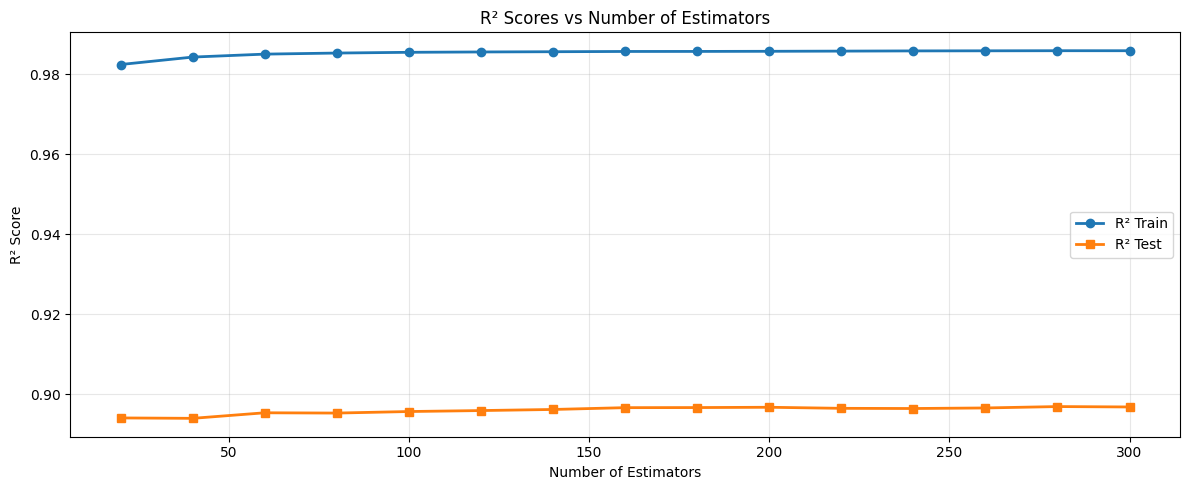

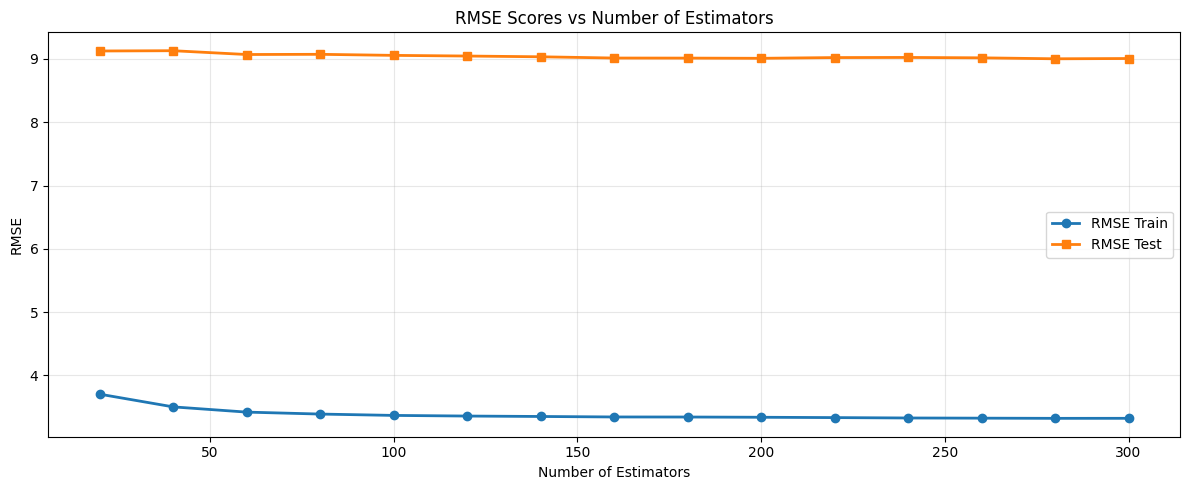

In [22]:
import math
from sklearn.metrics import mean_squared_error, r2_score

model_curve = RandomForestRegressor(random_state=42, n_jobs=-1)

r2_train, rmse_train = [], []
r2_test, rmse_test = [], []
n_estimators_range = list(range(20, 301, 20))

print("Antrenare RF pentru diferite valori de n_estimators...")
print(f"{'n_estimators':>12} {'R² Train':>10} {'R² Test':>10} {'RMSE Train':>12} {'RMSE Test':>12}")
print("-" * 60)

for i in n_estimators_range:
    model_curve.set_params(n_estimators=i)
    model_curve.fit(X_train, y_train)

    train_preds = model_curve.predict(X_train)
    r2_train.append(r2_score(y_train, train_preds))
    rmse_train.append(math.sqrt(mean_squared_error(y_train, train_preds)))

    test_preds = model_curve.predict(X_test)
    r2_test.append(r2_score(y_test, test_preds))
    rmse_test.append(math.sqrt(mean_squared_error(y_test, test_preds)))

    print(f"{i:>12} {r2_train[-1]:>10.4f} {r2_test[-1]:>10.4f} {rmse_train[-1]:>12.4f} {rmse_test[-1]:>12.4f}")


plt.figure(figsize=(12, 5))
plt.plot(n_estimators_range, r2_train, label='R² Train', marker='o', linewidth=2)
plt.plot(n_estimators_range, r2_test, label='R² Test', marker='s', linewidth=2)
plt.xlabel('Number of Estimators')
plt.ylabel('R² Score')
plt.title('R² Scores vs Number of Estimators')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(n_estimators_range, rmse_train, label='RMSE Train', marker='o', linewidth=2)
plt.plot(n_estimators_range, rmse_test, label='RMSE Test', marker='s', linewidth=2)
plt.xlabel('Number of Estimators')
plt.ylabel('RMSE')
plt.title('RMSE Scores vs Number of Estimators')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

-Performanța se stabilizează rapid.R² pe Test crește de la 0.8941 (n=20) la
0.8968 (n=200), o îmbunătățire de doar 0.0027 puncte. RMSE Test confirmă: scade
de la 9.13 la 9.00, o diferență de doar 0.13 unități.
-Punct de saturare în jurul lui 150-200 arbori. Diferența între n=200 și n=300
este nesemnificativă

Tuning prin GridSearchCV. Pentru identificarea sistematică a combinației optime de hiperparametri, aplicăm
GridSearchCV cu cross-validation 5-fold. Acoperim cei mai influenți hiperparametrii ai Random Forest: n_estimators, max_depth, min_samples_leaf

In [23]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_leaf': [1, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print(f"\nCei mai buni parametri: {grid_search.best_params_}")
print(f"Cel mai bun R² (cross-validation): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Cei mai buni parametri: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200}
Cel mai bun R² (cross-validation): 0.8937


Combinația optimă identificată este: n_estimators=200; max_depth=None; min_samples_leaf=4. Numărul de n_estimators identificat se află în zona de saturație identificată în curba precedentă. max_depth = None permite arborilor să crească complet. min_samples_leaf = 4 introduce o regularizare prevenind overfitting-ul prin obligarea fiecărei frunze să cpnțină minim 4 observații

Comparam modelul de random forest tuned cu cel baseline

In [24]:

comparatie_rf = pd.DataFrame({
    'RF Baseline (C)': {
        'n_estimators': 100,
        'min_samples_leaf': 1,
        'R² mediu (CV)': cv_scores.mean(),
        'R² deviație std': cv_scores.std(),
        'R² minim (fold)': cv_scores.min(),
        'R² maxim (fold)': cv_scores.max()
    },
    'RF Tuned (B)': {
        'n_estimators': 200,
        'min_samples_leaf': 4,
        'R² mediu (CV)': grid_search.best_score_,
        'R² deviație std': '-',
        'R² minim (fold)': '-',
        'R² maxim (fold)': '-'
    }
}).T

print("=== Random Forest: Baseline (CV) vs Tuned (CV) ===\n")
print(comparatie_rf.to_string())

=== Random Forest: Baseline (CV) vs Tuned (CV) ===

                n_estimators min_samples_leaf R² mediu (CV) R² deviație std R² minim (fold) R² maxim (fold)
RF Baseline (C)       100.00             1.00          0.89            0.01            0.88            0.90
RF Tuned (B)             200                4          0.89               -               -               -


Tuningul a adus o îmbunătățire de 0.0015 puncte pe R2. Tabelul de mai sus afișează doar R2 din GridSearchCV, care returnează o singură valoare medie, nu și statistici per-fold. Pentru o comparație completă, vom rula cross_validate separat pe modelul tunat în celula următoare

Luam aceleasi metrici si pentru RF pentru a compara cat mai optim modelele (MAE, MSE, RMSE, R2)

In [25]:
rf_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=4,
    random_state=42
)

scoring = {
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error',
    'R2': 'r2'
}

cv_results_rf = cross_validate(
    rf_tuned,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

mae_rf_scores = -cv_results_rf['test_MAE']
mse_rf_scores = -cv_results_rf['test_MSE']
rmse_rf_scores = np.sqrt(mse_rf_scores)
r2_rf_scores = cv_results_rf['test_R2']

print('=== Random Forest Tuned - CV 5-fold ===')
print(f'MAE:  {mae_rf_scores.mean():.4f} ± {mae_rf_scores.std():.4f}')
print(f'MSE:  {mse_rf_scores.mean():.4f} ± {mse_rf_scores.std():.4f}')
print(f'RMSE: {rmse_rf_scores.mean():.4f} ± {rmse_rf_scores.std():.4f}')
print(f'R²:   {r2_rf_scores.mean():.4f} ± {r2_rf_scores.std():.4f}')

=== Random Forest Tuned - CV 5-fold ===
MAE:  7.1307 ± 0.2227
MSE:  82.7176 ± 5.8578
RMSE: 9.0894 ± 0.3160
R²:   0.8937 ± 0.0066


Cu aceste valori disponibile avem acum aceleasi metrici ca la regersia liniara, permitand comparatia completa intre cele doua modele.

Compararea modelelor LR vs RF. Centralizăm metricile obținute pentru ambele modele într-un tabel comparativ.

In [26]:

comparatie_modele = pd.DataFrame({
    'Linear Regression': {
        'MAE': f'{mae_lr_scores.mean():.4f} ± {mae_lr_scores.std():.4f}',
        'MSE': f'{mse_lr_scores.mean():.4f} ± {mse_lr_scores.std():.4f}',
        'RMSE': f'{rmse_lr_scores.mean():.4f} ± {rmse_lr_scores.std():.4f}',
        'R²': f'{r2_lr_scores.mean():.4f} ± {r2_lr_scores.std():.4f}'
    },
    'Random Forest (tuned)': {
        'MAE': f'{mae_rf_scores.mean():.4f} ± {mae_rf_scores.std():.4f}',
        'MSE': f'{mse_rf_scores.mean():.4f} ± {mse_rf_scores.std():.4f}',
        'RMSE': f'{rmse_rf_scores.mean():.4f} ± {rmse_rf_scores.std():.4f}',
        'R²': f'{r2_rf_scores.mean():.4f} ± {r2_rf_scores.std():.4f}'
    }
}).T

print("=== Comparație modele (CV 5-fold pe X_train) ===\n")
print(comparatie_modele.to_string())

=== Comparație modele (CV 5-fold pe X_train) ===

                                   MAE               MSE             RMSE               R²
Linear Regression      7.3373 ± 0.1537  86.0551 ± 4.0043  9.2741 ± 0.2136  0.8894 ± 0.0040
Random Forest (tuned)  7.1307 ± 0.2227  82.7176 ± 5.8578  9.0894 ± 0.3160  0.8937 ± 0.0066


Regresia Liniară are deviații standard mai mici pe toate metricile, indicând o stabilitate superioară. Random Forest are performanță medie mai bună, dar cu variabilitate ușor mai mare între folduri. Decizia finală este că modelul Random Forest (tuned) este modelul ales pentru evaluarea finală pe setul de date

Diagrama comparativa cu bară de eroare

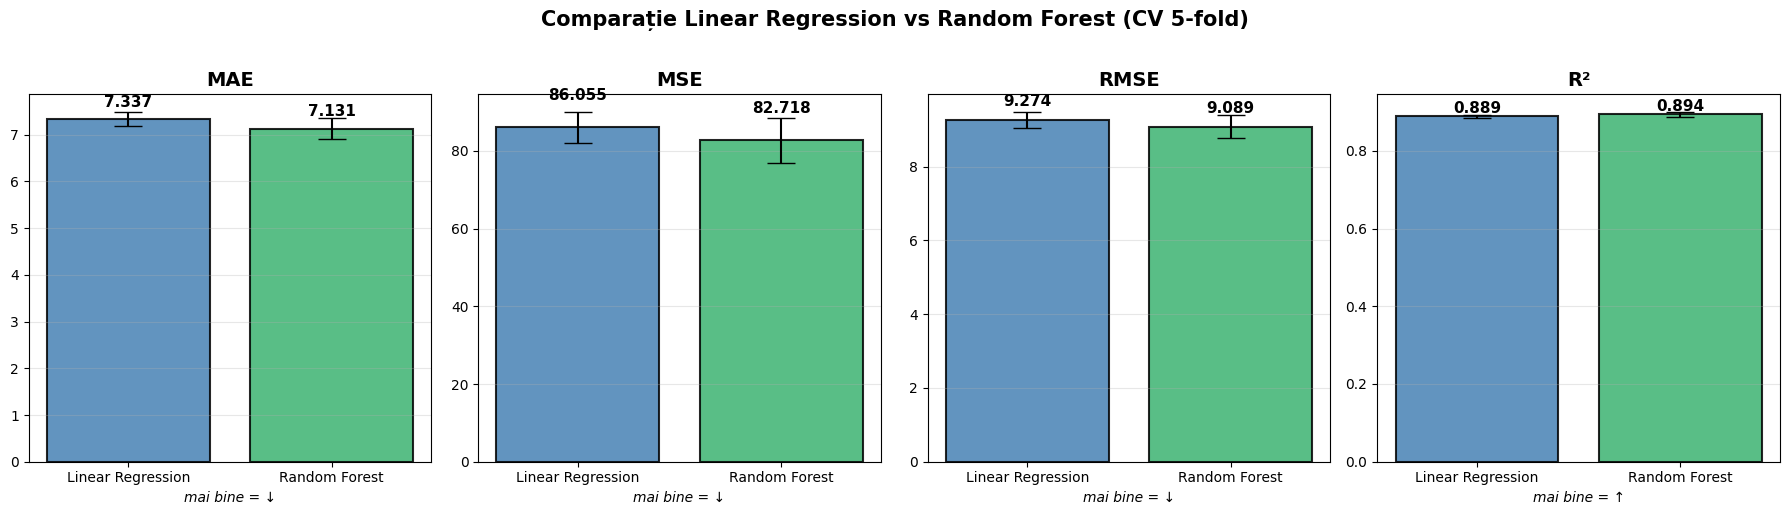

In [27]:

metrici = ['MAE', 'MSE', 'RMSE', 'R²']
means_lr = [mae_lr_scores.mean(), mse_lr_scores.mean(),
            rmse_lr_scores.mean(), r2_lr_scores.mean()]
means_rf = [mae_rf_scores.mean(), mse_rf_scores.mean(),
            rmse_rf_scores.mean(), r2_rf_scores.mean()]
stds_lr = [mae_lr_scores.std(), mse_lr_scores.std(),
           rmse_lr_scores.std(), r2_lr_scores.std()]
stds_rf = [mae_rf_scores.std(), mse_rf_scores.std(),
           rmse_rf_scores.std(), r2_rf_scores.std()]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, (metric, m_lr, m_rf, s_lr, s_rf) in enumerate(
    zip(metrici, means_lr, means_rf, stds_lr, stds_rf)
):
    bars = axes[i].bar(
        ['Linear Regression', 'Random Forest'],
        [m_lr, m_rf],
        yerr=[s_lr, s_rf],
        capsize=10,
        color=['steelblue', 'mediumseagreen'],
        alpha=0.85,
        edgecolor='black',
        linewidth=1.5
    )

    axes[i].set_title(f'{metric}', fontsize=14, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)


    for bar, val in zip(bars, [m_lr, m_rf]):
        axes[i].text(
            bar.get_x() + bar.get_width()/2.,
            bar.get_height() + max(s_lr, s_rf) * 1.2,
            f'{val:.3f}',
            ha='center',
            fontsize=11,
            fontweight='bold'
        )

    arrow = '↑' if metric == 'R²' else '↓'
    axes[i].set_xlabel(f'mai bine = {arrow}', fontsize=10, style='italic')

plt.suptitle('Comparație Linear Regression vs Random Forest (CV 5-fold)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Diagrama cu distribuția scorurilor pe folduri. Pe lângă mediile celor 4 metrici, vizualizăm și distribuția scorurilor pe cele 5 folds prin boxplot-uri

/tmp/ipykernel_15487/2075005132.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(
/tmp/ipykernel_15487/2075005132.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(
/tmp/ipykernel_15487/2075005132.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(
/tmp/ipykernel_15487/2075005132.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


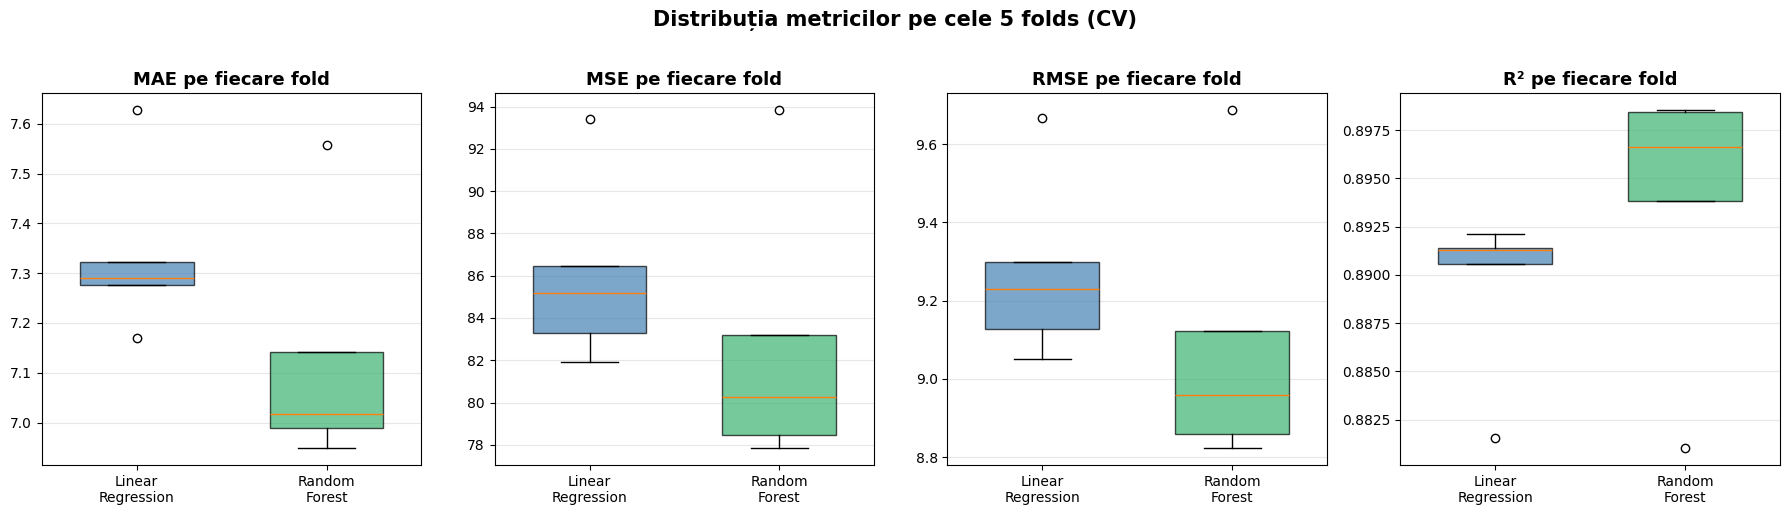

In [28]:

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

scoruri_per_metrica = [
    (mae_lr_scores, mae_rf_scores, 'MAE'),
    (mse_lr_scores, mse_rf_scores, 'MSE'),
    (rmse_lr_scores, rmse_rf_scores, 'RMSE'),
    (r2_lr_scores, r2_rf_scores, 'R²')
]

for i, (lr_data, rf_data, metric) in enumerate(scoruri_per_metrica):
    box = axes[i].boxplot(
        [lr_data, rf_data],
        labels=['Linear\nRegression', 'Random\nForest'],
        patch_artist=True,
        widths=0.6
    )
    box['boxes'][0].set_facecolor('steelblue')
    box['boxes'][1].set_facecolor('mediumseagreen')
    for box_obj in box['boxes']:
        box_obj.set_alpha(0.7)

    axes[i].set_title(f'{metric} pe fiecare fold', fontsize=13, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Distribuția metricilor pe cele 5 folds (CV)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Evaluarea finală pe setul de test. Antrenăm modelul Random Forest cu hiperparametrii optimi pe tot setul de antrenare
(7.122 înregistrări) și îl evaluăm o singură dată pe setul de test (1.257
înregistrări complet neatinse pe parcursul întregului proces de modelare).

In [29]:
rf_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=4,
    random_state=42
)


rf_final.fit(X_train, y_train)

y_pred_test = rf_final.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

print('=== Random Forest - EVALUARE FINALĂ pe X_test ===')
print(f'MAE:  {mae_test:.4f}')
print(f'MSE:  {mse_test:.4f}')
print(f'RMSE: {rmse_test:.4f}')
print(f'R²:   {r2_test:.4f}')

=== Random Forest - EVALUARE FINALĂ pe X_test ===
MAE:  7.0114
MSE:  80.9304
RMSE: 8.9961
R²:   0.8971


Modelul prezice scorul de recuperare cu o eroare medie de aproximativ 7 puncte, explicând 89.7% din variația Recovery_Score

Importanta features pentru random forest. Măsura feature_importance reflectă cât contribuie fiecare variabilă la reducerea erorii de predicție pe parcursul construirii arborilor

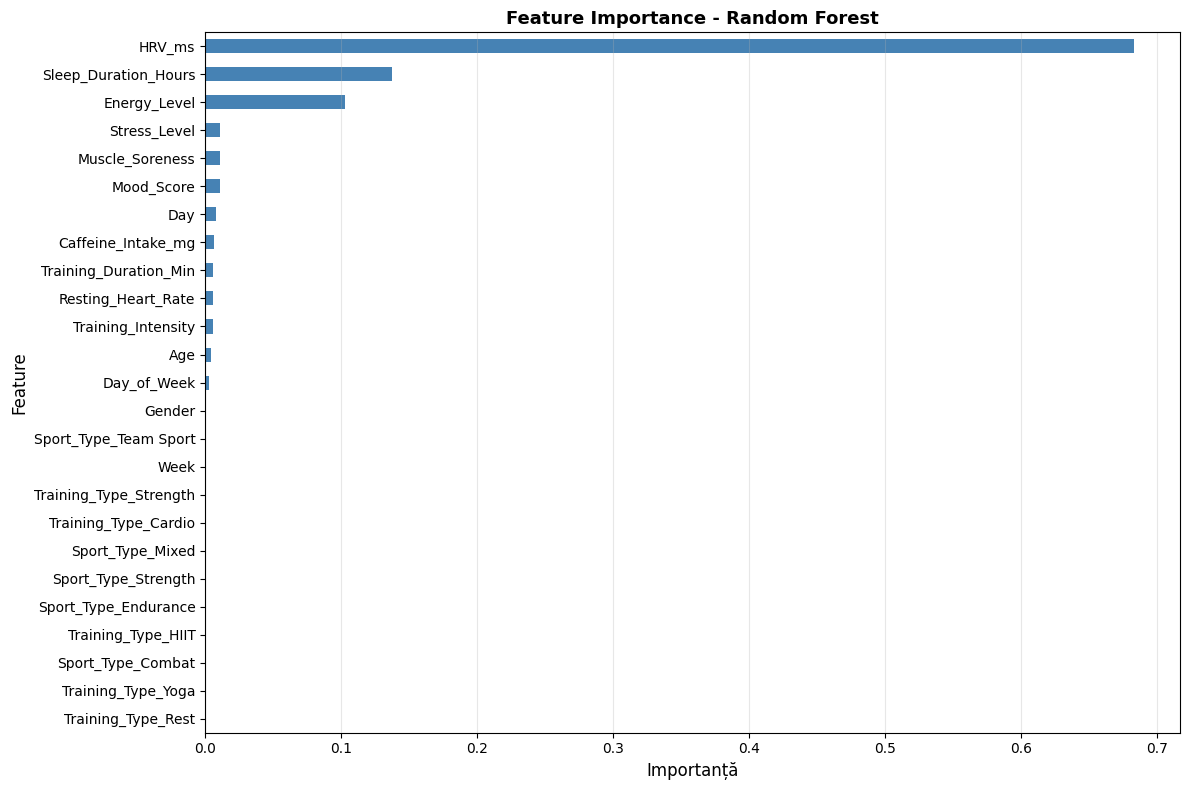


=== Top 10 features după importanță ===
                 cols  imp
               HRV_ms 0.68
 Sleep_Duration_Hours 0.14
         Energy_Level 0.10
         Stress_Level 0.01
      Muscle_Soreness 0.01
           Mood_Score 0.01
                  Day 0.01
   Caffeine_Intake_mg 0.01
Training_Duration_Min 0.01
   Resting_Heart_Rate 0.01


In [30]:

def plot_fi(fi):
    return fi.plot('cols', 'imp', 'barh', figsize=(12, 8), legend=False, color='steelblue')

feature_names = df.drop(columns=['Recovery_Score', 'Athlete_ID']).columns

fi = pd.DataFrame({
    'cols': feature_names,
    'imp': rf_final.feature_importances_
}).sort_values('imp', ascending=False)


ax = plot_fi(fi)
ax.set_xlabel('Importanță', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature Importance - Random Forest', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


print("\n=== Top 10 features după importanță ===")
print(fi.head(10).to_string(index=False))

HRV_ms este predictorul dominant cu cea mai mare importanță în model

Sleep_Duration_Hours, Stress_Level, Energy_Level, Muscle_Soreness sunt
următoarele features cu impact major



Comparare feature importance Regresie Liniară vs Random Forest. Realizăm acest pas pentru o validare suplimentară a importanței features-urilor

=== Feature Importance: Random Forest vs Linear Regression ===

               Feature  RF Importance  LR Coef (abs)  LR Coef (norm)
                HRV_ms           0.68          15.52            0.38
  Sleep_Duration_Hours           0.14           8.01            0.20
          Energy_Level           0.10           4.18            0.10
          Stress_Level           0.01           3.28            0.08
       Muscle_Soreness           0.01           3.08            0.08
            Mood_Score           0.01           1.19            0.03
                   Day           0.01           0.64            0.02
    Caffeine_Intake_mg           0.01           0.31            0.01
 Training_Duration_Min           0.01           0.08            0.00
    Resting_Heart_Rate           0.01           0.87            0.02
    Training_Intensity           0.01           0.04            0.00
                   Age           0.00           0.46            0.01
           Day_of_Week           0.00  

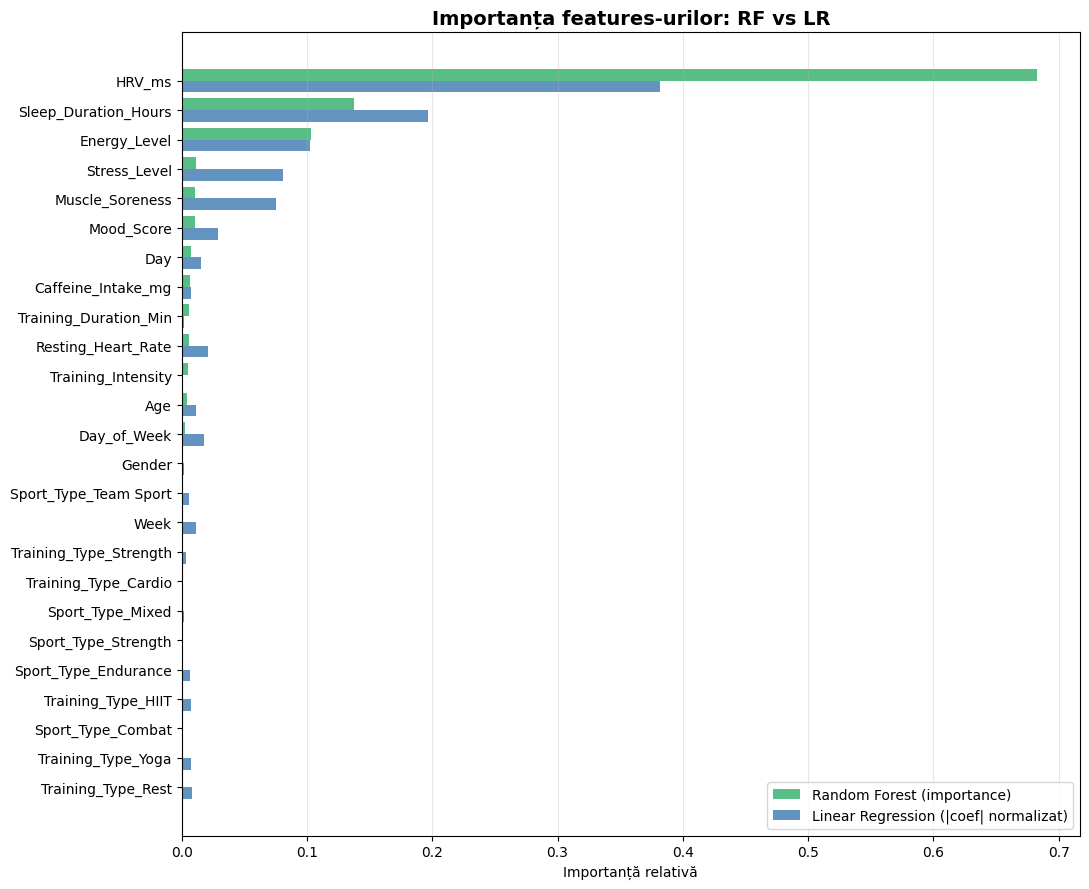

In [31]:

feature_names = df.drop(columns=['Recovery_Score', 'Athlete_ID']).columns


comparatie_features = pd.DataFrame({
    'Feature': feature_names,
    'RF Importance': rf_final.feature_importances_,
    'LR Coef (abs)': np.abs(lr_inspect.coef_)
})

comparatie_features['LR Coef (norm)'] = (
    comparatie_features['LR Coef (abs)'] / comparatie_features['LR Coef (abs)'].sum()
)

comparatie_features = comparatie_features.sort_values('RF Importance', ascending=False)

print("=== Feature Importance: Random Forest vs Linear Regression ===\n")
print(comparatie_features.to_string(index=False))


fig, ax = plt.subplots(figsize=(11, 9))

y_pos = np.arange(len(comparatie_features))
width = 0.4

ax.barh(y_pos - width/2, comparatie_features['RF Importance'],
        width, label='Random Forest (importance)', color='mediumseagreen', alpha=0.85)
ax.barh(y_pos + width/2, comparatie_features['LR Coef (norm)'],
        width, label='Linear Regression (|coef| normalizat)', color='steelblue', alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(comparatie_features['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Importanță relativă')
ax.set_title('Importanța features-urilor: RF vs LR', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Analiza vizuală a predicțiilor

- Predicted vs Actual — arată concordanța dintre valorile prezise și cele reale.
Un model perfect ar avea toate punctele exact pe linia y = x.
- Grafic Rezidual — arată distribuția erorilor (y_real - y_prezis). Idealul este
o distribuție uniformă în jurul liniei zero, fără patterns sistematice.

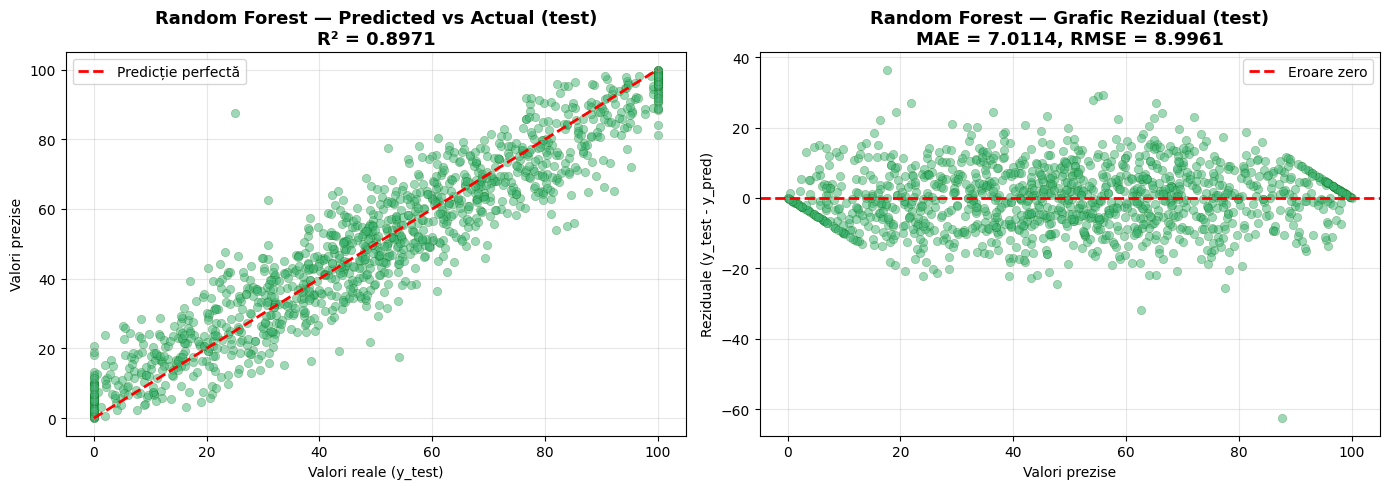

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(y_test, y_pred_test, alpha=0.5, color='mediumseagreen', edgecolors='darkgreen', linewidth=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Predicție perfectă')
axes[0].set_xlabel('Valori reale (y_test)')
axes[0].set_ylabel('Valori prezise')
axes[0].set_title(f'Random Forest — Predicted vs Actual (test)\nR² = {r2_test:.4f}',
                  fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)


residuals_test = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals_test, alpha=0.5, color='mediumseagreen',
                edgecolors='darkgreen', linewidth=0.3)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2, label='Eroare zero')
axes[1].set_xlabel('Valori prezise')
axes[1].set_ylabel('Reziduale (y_test - y_pred)')
axes[1].set_title(f'Random Forest — Grafic Rezidual (test)\nMAE = {mae_test:.4f}, RMSE = {rmse_test:.4f}',
                  fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Predicted vs Actual:
- Punctele se grupează strâns în jurul liniei roșii (predicția perfectă),
confirmând vizual valoarea R² = 0.897
- Se observă acumulări verticale la limitele scalei (0 și 100) — o consecință
directă a trunchierii variabilei țintă identificate în EDA. Modelul prezice valori
variate pentru înregistrările aglomerate artificial la limitele intervalului.
- Câțiva outlieri izolați apar pentru cazurile în care modelul greșește semnificativ
(de exemplu, atleți cu Recovery_Score real ≈ 30 dar prezis ≈ 88)

Grafic Rezidual:
- Reziduurile sunt distribuite relativ uniform deasupra și sub linia zero,
indicând absența unui bias sistematic
- Majoritatea reziduurilor sunt în intervalul +-20, cu doar câteva valori extreme
- Nu se observă patterns clare (curbe, conuri), confirmând că presupunerea de
homoscedasticitate este respectată
- Forma triunghiulară la stânga (în jurul valorilor prezise mici) reflectă din
nou efectul trunchierii la 0